# 3D Liver Tumor Segmentation
Author: Mateusz Pilch

### Loading Data

In [1]:
import os, torch, numpy as np, albumentations as A, nibabel as nib
from matplotlib import pyplot as plt; from glob import glob;
from torch.utils.data import random_split, Dataset, DataLoader
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

class SegmentationDataset(Dataset):
    
    def __init__(self, transformations = None, cnt = 1000):

        im_nii_paths = sorted(glob(f"data/imagesTr/*.nii"))
        gt_nii_paths = sorted(glob(f"data/labelsTr/*.nii"))
        
        self.ims, self.gts = self.get_slices(im_nii_paths, gt_nii_paths, cnt)
        self.transformations = transformations
        self.cnt = cnt

        assert len(self.ims) == len(self.gts)

    def __getitem__(self, idx):
        
        im, gt = self.ims[idx], self.gts[idx]
        if self.transformations: im, gt = self.apply_transformations(im, gt)
        
        im = self.preprocess_im(im)
        return im.float(), gt.unsqueeze(0).long()
    
    def __len__(self): return len(self.ims)

    def preprocess_im(self, im): 
        
        max_val = torch.max(im)
        im[im < 0] = 0
        
        return im / max_val
    
    def get_slices(self, im_nii_paths, gt_nii_paths, cnt): 
        
        ims, gts = [], []
        
        for index, (im_nii, gt_nii) in enumerate(zip(im_nii_paths, gt_nii_paths)):
            if index == cnt: break
            nii_im_data, nii_gt_data  = self.read_nii(im_nii, gt_nii)
            
            for idx, (im, gt) in enumerate(zip(nii_im_data, nii_gt_data)):
                if len(np.unique(gt)) > 1: ims.append(im); gts.append(gt)
            print(f"CT nifti file number {index + 1} converted") 
        return ims, gts

    def read_nii(self, im, gt): return nib.load(im).get_fdata().transpose(2, 1, 0), nib.load(gt).get_fdata().transpose(2, 1, 0)
    
    def apply_transformations(self, im, gt): transformed = self.transformations(image = im, mask = gt); return transformed["image"], transformed["mask"]

def get_dls(transformations, bs, split, cnt, ns = 0):
       
    ds = SegmentationDataset(transformations = transformations,cnt = cnt)
    
    tr_len = int(len(ds) * split[0])
    val_len = int(len(ds) * split[1])
    test_len = len(ds) - (tr_len + val_len)
    
    tr_ds, val_ds, test_ds = torch.utils.data.random_split(ds, [tr_len, val_len, test_len])
        
    print(f"Trening set size: {len(tr_ds)}")
    print(f"\nValidation set size: {len(val_ds)}")
    print(f"Test set size: {len(test_ds)}\n")
    
    tr_dl  = DataLoader(dataset = tr_ds, batch_size = bs, shuffle = True, num_workers = ns)
    val_dl = DataLoader(dataset = val_ds, batch_size = bs, shuffle = False, num_workers = ns)
    test_dl = DataLoader(dataset = test_ds, batch_size = 1, shuffle = False, num_workers = ns)
    
    return tr_dl, val_dl, test_dl

im_h, im_w = 256, 256
split = [0.75, 0.20, 0.05]
batch_size = 8
n_cls = 3
cnt = 1000

transformations = A.Compose([A.Resize(im_h, im_w), ToTensorV2(transpose_mask = True)])
tr_dl, val_dl, test_dl = get_dls(transformations = transformations, split=split, bs = batch_size, cnt=cnt)

c:\Users\Mati\anaconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


CT nifti file number 1 converted
CT nifti file number 2 converted
CT nifti file number 3 converted
CT nifti file number 4 converted
CT nifti file number 5 converted
CT nifti file number 6 converted
CT nifti file number 7 converted
CT nifti file number 8 converted
CT nifti file number 9 converted
CT nifti file number 10 converted
CT nifti file number 11 converted
CT nifti file number 12 converted
CT nifti file number 13 converted
CT nifti file number 14 converted
CT nifti file number 15 converted
CT nifti file number 16 converted
CT nifti file number 17 converted
CT nifti file number 18 converted
CT nifti file number 19 converted
CT nifti file number 20 converted
CT nifti file number 21 converted
CT nifti file number 22 converted
CT nifti file number 23 converted
CT nifti file number 24 converted
CT nifti file number 25 converted
CT nifti file number 26 converted
CT nifti file number 27 converted
CT nifti file number 28 converted
CT nifti file number 29 converted
CT nifti file number 30

### Metrics

In [ ]:
import segmentation_models_pytorch as smp, time
from torch.nn import functional as F

class Metrics():
    
    def __init__(self, pred, gt, loss_fn, eps = 1e-10, n_cls = None, device = "cpu"):
        self.pred, self.gt = torch.softmax(pred, dim=1), gt
        self.pred = torch.argmax(pred, dim = 1) > 0
        self.loss_fn, self.eps, self.n_cls, self.pred_, self.device = loss_fn, eps, n_cls, pred, device 
        
    def to_contiguous(self, inp): return inp.contiguous().view(-1) 
    
    def PA(self):
        with torch.no_grad():
            match = torch.eq(self.pred, self.gt).int()
        
        return float(match.sum()) / float(match.numel())

    def mIoU(self):
        with torch.no_grad():
            
            pred, gt = self.to_contiguous(self.pred), self.to_contiguous(self.gt)
            iou_per_class = []
            
            for c in range(self.n_cls):       
                match_pred = pred == c
                match_gt = gt == c

                if match_gt.long().sum().item() == 0: iou_per_class.append(np.nan)
                    
                else:      
                    intersect = torch.logical_and(match_pred, match_gt).sum().float().item()
                    union = torch.logical_or(match_pred, match_gt).sum().float().item()

                    iou = (intersect + self.eps) / (union + self.eps)
                    iou_per_class.append(iou)
                    
            return np.nanmean(iou_per_class)
    
    def loss(self): return self.loss_fn(self.pred_, self.gt.squeeze(1))

def tic_toc(start_time = None): return time.time() if start_time == None else time.time() - start_time

### Training

In [4]:
def train(model, tr_dl, val_dl, loss_fn, opt, device, epochs, save_prefix, threshold=0.0005, n_cls= None):
    tr_loss, tr_pa, tr_iou = [], [], []
    val_loss, val_pa, val_iou = [], [], []
    best_loss, not_improve, early_stop_threshold = 0, 0, 10
    os.makedirs("saved_models", exist_ok=True)

    model.to(device, non_blocking=True)
    train_start = tic_toc()
    print("Start training process...")
    
    for epoch in range(1, epochs + 1):
        tic = tic_toc()
        tr_loss_, tr_iou_, tr_pa_ = 0, 0, 0
        
        model.train()
        print(f"\nEpoch {epoch} train process is started...")
        for idx, batch in enumerate(tqdm(tr_dl)):
            ims, gts = batch
            ims, gts = ims.to(device), gts.to(device).long()

            preds = model(ims)

            met = Metrics(preds, gts, loss_fn, n_cls=n_cls)
            loss_ = met.loss_fn(preds, gts).requires_grad_()

            tr_loss_ = 1 - loss_.item()
            tr_iou_ = met.mIoU()
            tr_pa_ = met.PA()

            loss_.backward()
            opt.step()
            opt.zero_grad()

        print(f"Epoch {epoch} validation process is started...")
        model.eval()
        val_loss_, val_iou_, val_pa_ = 0, 0, 0

        with torch.no_grad():
            for idx, batch in enumerate(tqdm(val_dl)):
                ims, gts = batch
                ims, gts = ims.to(device), gts.to(device)

                preds = model(ims)

                met = Metrics(preds, gts, loss_fn, n_cls = n_cls)

                val_loss_ = 1 - met.loss_fn(preds, gts).item()
                val_iou_ = met.mIoU()
                val_pa_ = met.PA()
                
        print(f"Epoch {epoch} train process is completed.\n")


        print(f"Epoch {epoch} train process results: \n")
        print(f"Train Time              -> {tic_toc(tic):.3f} sec")
        print(f"Train Dice Loss         -> {tr_loss_:.3f}")
        print(f"Train IoU               -> {tr_iou_:.3f}")
        print(f"Train PA                -> {tr_pa_:.3f}")
        print(f"Validation Dice Loss    -> {val_loss_:.3f}")
        print(f"Validation IoU          -> {val_iou_:.3f}")
        print(f"Validation PA           -> {val_pa_:.3f}\n")

        tr_loss.append(tr_loss_)
        tr_iou.append(tr_iou_)
        tr_pa.append(tr_pa_)

        val_loss.append(val_loss_)
        val_iou.append(val_iou_)
        val_pa.append(val_pa_)

        if best_loss < (val_loss_ - threshold):
            print(f"Dice loss increase from {best_loss:.3f} to {val_loss_:.3f}!")
            best_loss = val_loss_
            
            print("Saving the model with the best dice loss value...")
            torch.save(model, f"saved_models/{save_prefix}_best_model.pt")
        else:
            not_improve += 1
            print(f"Dice loss did not increase for {not_improve} epoch(s)!")
            if not_improve == early_stop_threshold:
                print(f"Loss value did not increase for {early_stop_threshold} epochs! Stopping training process...")
                break
            
    print(f"Train process is completed in {(tic_toc(train_start)) / 60:.3f} minutes.")
    
    return {"tr_loss": tr_loss, "tr_iou": tr_iou, "tr_pa": tr_pa,
            "val_loss": val_loss, "val_iou": val_iou, "val_pa": val_pa}

### Traning model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

lr = 0.0003
loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)

model = smp.UnetPlusPlus(classes = n_cls, in_channels = 1)
optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay=1e-5)

history = train(model = model, tr_dl = tr_dl, val_dl = val_dl,
                loss_fn = loss_fn, opt = optimizer, device = device,
                epochs = 25, save_prefix = "liver", n_cls = n_cls)

Start training process...

Epoch 1 train process is started...


100%|██████████| 602/602 [02:15<00:00,  4.43it/s]


Epoch 1 validation process is started...


100%|██████████| 161/161 [00:19<00:00,  8.43it/s]


Epoch 1 train process is completed.

Epoch 1 train process results: 

Train Time              -> 154.850 sec
Train Dice Loss         -> 0.844
Train IoU               -> 0.640
Train PA                -> 0.990
Validation Dice Loss    -> 0.981
Validation IoU          -> 0.948
Validation PA           -> 0.946

Dice loss increase from 0.000 to 0.981!
Saving the model with the best dice loss value...

Epoch 2 train process is started...


...

Epoch 14 train process is completed.

Epoch 14 train process results: 

Train Time              -> 159.028 sec
Train Dice Loss         -> 0.663
Train IoU               -> 0.488
Train PA                -> 0.976
Validation Dice Loss    -> 0.968
Validation IoU          -> 0.902
Validation PA           -> 0.939

Dice loss did not increase for 9 epoch(s)!

Epoch 15 train process is started...


100%|██████████| 602/602 [02:22<00:00,  4.23it/s]


Epoch 15 validation process is started...


100%|██████████| 161/161 [00:14<00:00, 11.04it/s]

Epoch 15 train process is completed.

Epoch 15 train process results: 

Train Time              -> 156.975 sec
Train Dice Loss         -> 0.992
Train IoU               -> 0.976
Train PA                -> 0.997
Validation Dice Loss    -> 0.982
Validation IoU          -> 0.947
Validation PA           -> 0.945

Dice loss did not increase for 10 epoch(s)!
Loss value did not increase for 10 epochs! Stopping training process...
Train process is completed in 38.351 minutes.


### Model Performance Metrics

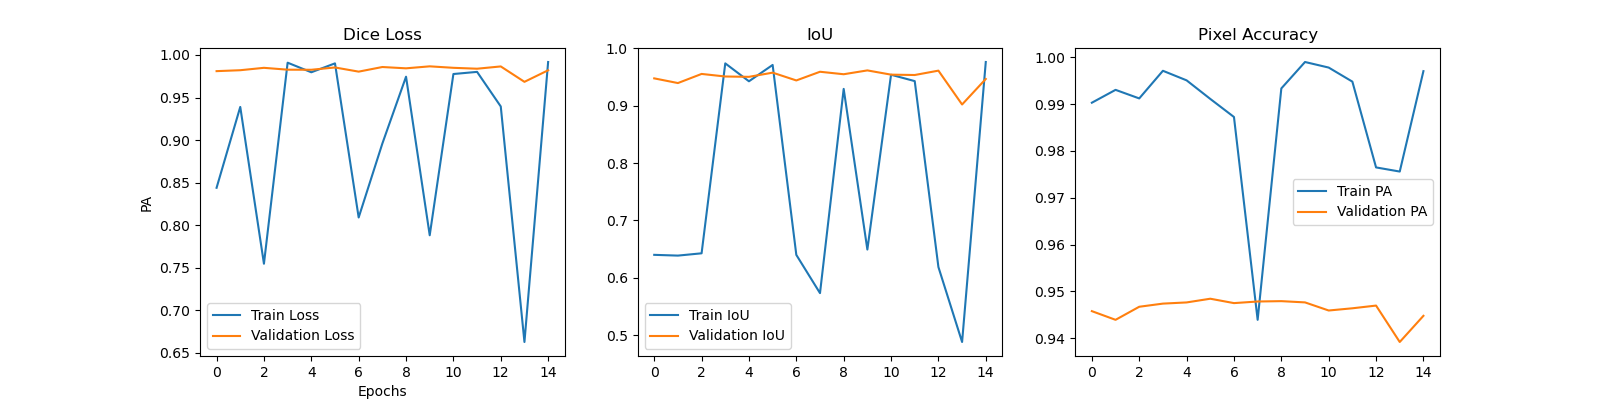

In [6]:
figure, axis = plt.subplots(1, 3, figsize=(16, 4))

axis[0].plot(history.get('tr_loss'), label="Train Loss")
axis[0].plot(history.get('val_loss'), label="Validation Loss")
axis[0].set_title("Dice Loss")
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("Loss") 
axis[0].legend() 

axis[1].plot(history.get('tr_iou'), label="Train IoU")
axis[1].plot(history.get('val_iou'), label="Validation IoU")
axis[1].set_title("IoU")
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("IoU") 
axis[1].legend() 

axis[2].plot(history.get('tr_pa'), label="Train PA")
axis[2].plot(history.get('val_pa'), label="Validation PA")
axis[2].set_title("Pixel Accuracy")
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("PA") 
axis[2].legend() 

plt.show()

### Validation Set Prediction

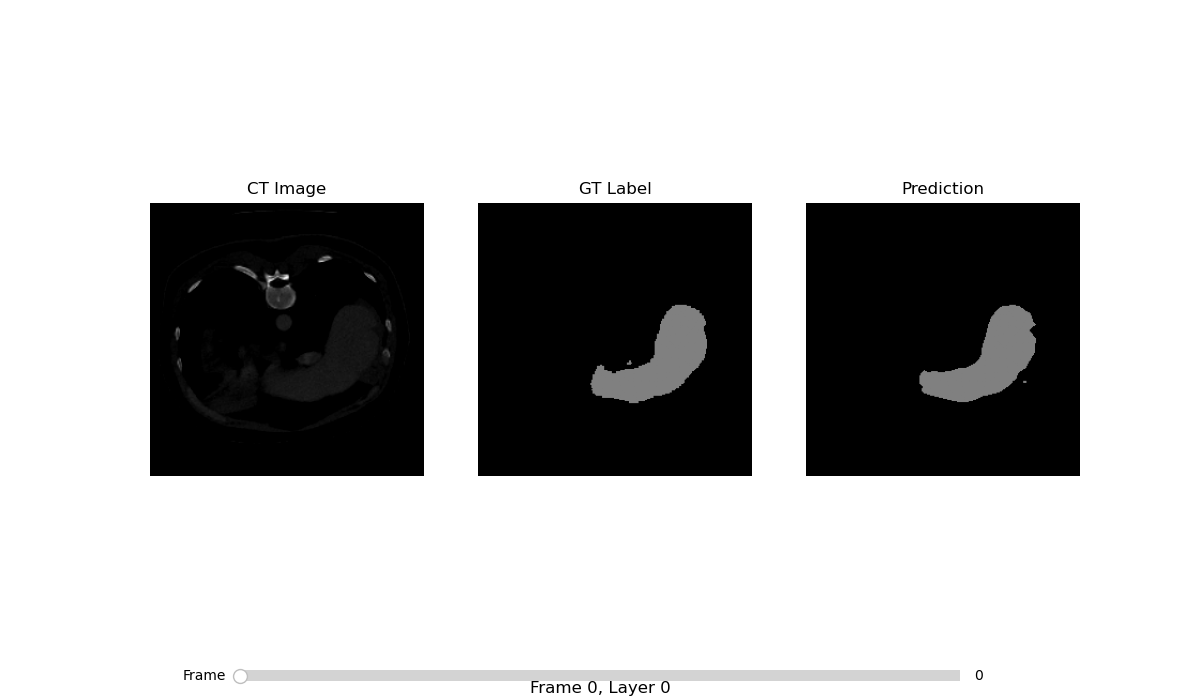

In [7]:
%matplotlib widget
from matplotlib.widgets import Slider

model = torch.load("saved_models/liver_best_model.pt", weights_only=False)

def create_animation_predictions(test, model, device):
    ims, gts, preds = [], [], []

    for idx, data in enumerate(test):
        im, gt = data

        with torch.no_grad():
            output = model(im.to(device))
            pred = torch.softmax(output, dim=1)
            pred = pred.argmax(dim = 1)

        ims.append(im.cpu().numpy())
        gts.append(gt.cpu().numpy())
        preds.append(pred.cpu().numpy())

    ims, gts = np.array(ims), np.array(gts)
    preds = np.array(preds)

    num_frames, num_layers = ims.shape[0], ims.shape[1]

    fig, ax = plt.subplots(1, 3, figsize=(12, 7))
    plt.subplots_adjust(bottom=0.25 if num_layers > 1 else 0.15)

    im_img = ax[0].imshow(np.squeeze(ims[0]), cmap='gray')
    im_lbl = ax[1].imshow(np.squeeze(gts[0]), cmap='gray', vmin=0, vmax=2)
    im_pred = ax[2].imshow(np.squeeze(preds[0]), cmap='gray', vmin=0, vmax=2)

    ax[0].set_title('CT Image')
    ax[1].set_title('GT Label')
    ax[2].set_title('Prediction')

    for a in ax:
        a.axis('off')

    text = fig.text(0.5, 0.01, f'Frame 0, Layer 0', ha='center', fontsize=12)

    ax_slider_frame = plt.axes([0.2, 0.02, 0.6, 0.03], facecolor='lightgray')
    slider_frame = Slider(ax_slider_frame, 'Frame', 0, num_frames - 1, valinit=0, valstep=1)

    def update_display(val):
        frame = int(slider_frame.val)

        im_img.set_array(np.squeeze(ims[frame]))
        im_lbl.set_array(np.squeeze(gts[frame]))
        im_pred.set_array(np.squeeze(preds[frame]))

        text.set_text(f'Frame {frame}')
        fig.canvas.draw_idle()

    slider_frame.on_changed(update_display)

    plt.show()
    
create_animation_predictions(test_dl, model, device)

### 3D Segmentation Prediction

CT nifti file number 1 converted


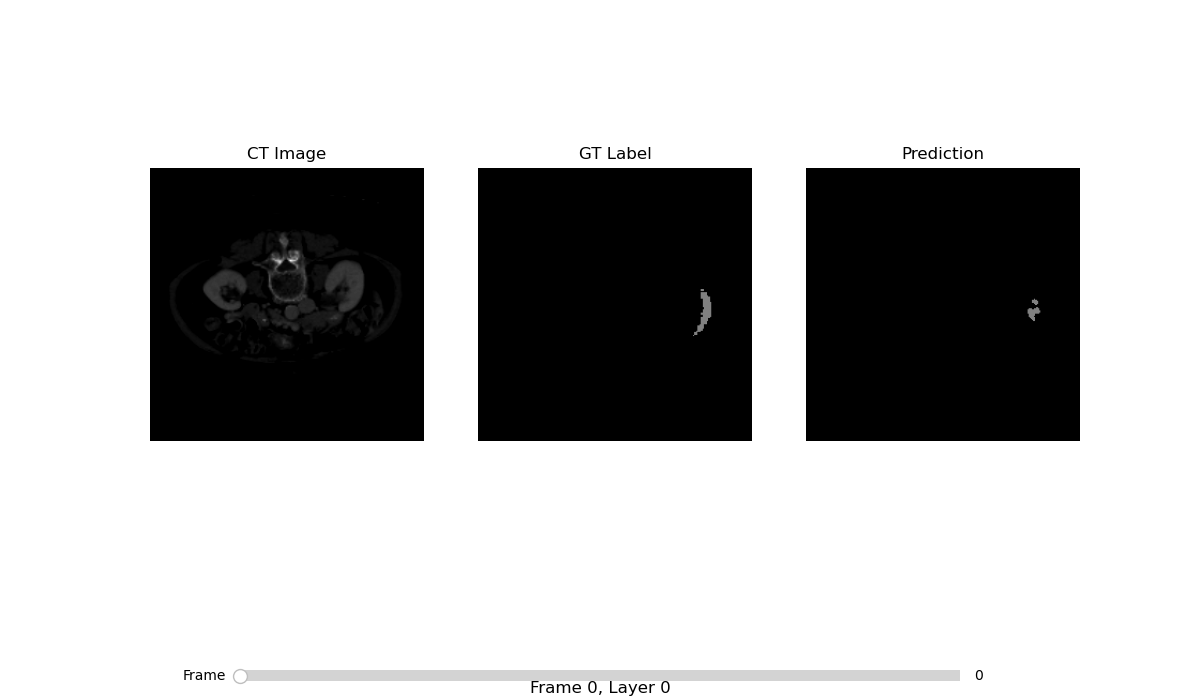

In [8]:
%matplotlib widget
from matplotlib.widgets import Slider

model = torch.load("saved_models/liver_best_model.pt", weights_only=False)

def create_animation_predictions(model, device):
    ims, gts, preds = [], [], []
    im_h, im_w = 256, 256
    transformations = A.Compose([A.Resize(im_h, im_w), ToTensorV2(transpose_mask = True)])

    ds = SegmentationDataset(transformations = transformations,cnt = 1)

    tr_dl  = DataLoader(dataset = ds, batch_size = 2, shuffle = False, num_workers = 0)
    for idx, data in enumerate(tr_dl):
        im, gt = data

        with torch.no_grad():
            output = model(im.to(device))
            pred = torch.softmax(output, dim=1)
            pred = pred.argmax(dim = 1)

        ims.append(im.cpu().numpy())
        gts.append(gt.cpu().numpy())
        preds.append(pred.cpu().numpy())

    ims, gts = np.array(ims), np.array(gts)
    preds = np.array(preds)

    num_frames, num_layers = ims.shape[0], ims.shape[1]

    fig, ax = plt.subplots(1, 3, figsize=(12, 7))
    plt.subplots_adjust(bottom=0.25 if num_layers > 1 else 0.15)

    im_img = ax[0].imshow(np.squeeze(ims[0][0]), cmap='gray')
    im_lbl = ax[1].imshow(np.squeeze(gts[0][0]), cmap='gray', vmin=0, vmax=2)
    im_pred = ax[2].imshow(np.squeeze(preds[0][0]), cmap='gray', vmin=0, vmax=2)

    ax[0].set_title('CT Image')
    ax[1].set_title('GT Label')
    ax[2].set_title('Prediction')

    for a in ax:
        a.axis('off')

    text = fig.text(0.5, 0.01, f'Frame 0, Layer 0', ha='center', fontsize=12)

    ax_slider_frame = plt.axes([0.2, 0.02, 0.6, 0.03], facecolor='lightgray')
    slider_frame = Slider(ax_slider_frame, 'Frame', 0, num_frames - 1, valinit=0, valstep=1)

    def update_display(val):
        frame = int(slider_frame.val)

        im_img.set_array(np.squeeze(ims[frame][0]))
        im_lbl.set_array(np.squeeze(gts[frame][0]))
        im_pred.set_array(np.squeeze(preds[frame][0]))

        text.set_text(f'Frame {frame}')
        fig.canvas.draw_idle()

    slider_frame.on_changed(update_display)

    plt.show()
    
create_animation_predictions(model, device)